# FinSentinel — Notebook 2: Evaluation
Run this notebook after Notebook 1 has completed and saved models to Drive.
No retraining required. Loads all artifacts and models from Google Drive.


In [1]:

!pip install yfinance stable-baselines3[extra] gymnasium anthropic ta plotly -q
!pip install tensorflow -q
!pip install groq
print("done")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 932.0/932.0 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 18.0 MB/s eta 0:00:00
done


In [2]:
import groq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import yfinance as yf
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (precision_recall_fscore_support,
                             confusion_matrix, ConfusionMatrixDisplay)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import EvalCallback
import anthropic
import warnings, json, os
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

TICKERS = ['AAPL', 'TSLA', 'AMZN', 'MSFT', 'GOOGL','NVDA', 'AMD','JPM', 'GS', 'JNJ', 'PFE','XOM', 'CVX','NFLX', 'DIS']
START_DATE    = '2020-01-01'
TRAIN_END     = '2023-12-31'
TEST_START    = '2024-01-01'
END_DATE      = '2024-12-31'
SEQUENCE_LEN  = 20
CONTAMINATION = 0.05
ENSEMBLE_W_IF = 0.40
ENSEMBLE_W_DL = 0.60
RL_TIMESTEPS  = 150_000
ALERT_THRESH  = 0.95


GROQ_API_KEY = os.environ.get("GROQ_API_KEY", "")

np.random.seed(42)
tf.random.set_seed(42)

print("Imports complete")
print(f"  TensorFlow : {tf.__version__}")
print(f"  Tickers    : {TICKERS}")
print(f"  Train      : {START_DATE} to {TRAIN_END}")
print(f"  Test       : {TEST_START} to {END_DATE}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Imports complete
  TensorFlow : 2.19.0
  Tickers    : ['AAPL', 'TSLA', 'AMZN', 'MSFT', 'GOOGL', 'NVDA', 'AMD', 'JPM', 'GS', 'JNJ', 'PFE', 'XOM', 'CVX', 'NFLX', 'DIS']
  Train      : 2020-01-01 to 2023-12-31
  Test       : 2024-01-01 to 2024-12-31


In [4]:
def compute_features(df):
    """
    Compute 16 technical features optimised for anomaly detection.

    Features:
      Price:   log_returns, volatility_5d, volatility_20d, vol_ratio, z_vs_ma20,
               z_vs_ma50, hl_range, hl_ratio, gap
      Volume:  volume_ratio, volume_z
      Momentum: RSI-normalized, MACD-normalized, BB-position
      Trend:   close_above_ma50 (binary)
    """
    f = pd.DataFrame(index=df.index)

    close = df['Close']
    vol   = df['Volume']

    # price

    f['log_returns']   = np.log(close / close.shift(1))
    f['volatility_5']  = f['log_returns'].rolling(5).std()
    f['volatility_20'] = f['log_returns'].rolling(20).std()
    f['vol_ratio']     = f['volatility_5'] / (f['volatility_20'] + 1e-9)

    ma20 = close.rolling(20).mean(); std20 = close.rolling(20).std()
    ma50 = close.rolling(50).mean(); std50 = close.rolling(50).std()
    f['z_vs_ma20'] = (close - ma20) / (std20 + 1e-9)
    f['z_vs_ma50'] = (close - ma50) / (std50 + 1e-9)

    f['hl_range'] = (df['High'] - df['Low']) / (close + 1e-9)
    hl_ma = f['hl_range'].rolling(10).mean()
    f['hl_ratio'] = f['hl_range'] / (hl_ma + 1e-9)
    f['gap']      = (df['Open'] - close.shift(1)) / (close.shift(1) + 1e-9)

    # volume

    vol_ma = vol.rolling(20).mean()
    f['volume_ratio'] = vol / (vol_ma + 1e-9)
    f['volume_z']     = (vol - vol_ma) / (vol.rolling(20).std() + 1e-9)


    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rsi   = 100 - (100 / (1 + gain / (loss + 1e-9)))
    f['rsi_norm']  = (rsi - 50) / 50          # scale to [-1, 1]

    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    f['macd_norm'] = (ema12 - ema26) / (close + 1e-9)

    f['bb_pos'] = (close - ma20) / (2 * std20 + 1e-9)

   # trend
    f['above_ma50'] = (close > ma50).astype(float)

    f.dropna(inplace=True)
    return f




In [11]:
FEATURE_NAMES = list(feature_data[TICKERS[0]].columns)
def build_lstm_ae(n_features: int, seq_len: int, latent_dim: int = 32):
    """
    Stacked LSTM Autoencoder.
    Encoder: LSTM(64) → LSTM(latent_dim)
    Decoder: RepeatVector → LSTM(latent_dim) → LSTM(64) → TimeDistributed(Dense)
    Loss  : MSE (reconstruction error)
    """
    inp = keras.Input(shape=(seq_len, n_features), name='input')

    # encoder
    x = layers.LSTM(64, return_sequences=True, name='enc1')(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(latent_dim, return_sequences=False, name='enc2')(x)

    # bottleneck
    x = layers.RepeatVector(seq_len, name='bottleneck')(x)
    x = layers.LSTM(latent_dim, return_sequences=True, name='dec1')(x)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(64, return_sequences=True, name='dec2')(x)
    out = layers.TimeDistributed(layers.Dense(n_features), name='output')(x)

    model = keras.Model(inp, out, name='LSTM_Autoencoder')
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
    return model


def make_sequences(arr: np.ndarray, seq_len: int) -> np.ndarray:
    return np.array([arr[i:i + seq_len] for i in range(len(arr) - seq_len)])


def reconstruction_score(model, X_seq: np.ndarray) -> np.ndarray:
    """Per-sample MSE normalised to [0, 1]."""
    X_pred = model.predict(X_seq, verbose=0)
    mse    = np.mean((X_seq - X_pred) ** 2, axis=(1, 2))
    return (mse - mse.min()) / ((mse.max() - mse.min()) + 1e-9)


lstm_models, lstm_scores = {}, {}

n_feat = len(FEATURE_NAMES)
print(f" Building LSTM Autoencoders with seq_len={SEQUENCE_LEN}  n_features={n_feat}\n")

for ticker in TICKERS:
    print(f"  {ticker}  training")

    feat   = feature_data[ticker]
    scaler = StandardScaler()
    X_sc   = scaler.fit_transform(feat)
    X_seq  = make_sequences(X_sc, SEQUENCE_LEN)

    # 80/20 split — train only on 'normal' history
    split    = int(0.8 * len(X_seq))
    X_train  = X_seq[:split]

    model = build_lstm_ae(n_feat, SEQUENCE_LEN)
    cb = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=7, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
    ]
    hist = model.fit(
        X_train, X_train,
        epochs=50, batch_size=32,
        validation_split=0.1,
        callbacks=cb, verbose=0
    )

    scores = reconstruction_score(model, X_seq)
    lstm_models[ticker] = {'model': model, 'scaler': scaler}
    lstm_scores[ticker] = scores

    best_loss = min(hist.history['val_loss'])
    print(f"   val_loss={best_loss:.5f} scoring {len(scores)} windows")

print("\n LSTM training complete")


 Building LSTM Autoencoders with seq_len=20  n_features=15

  AAPL  training
   val_loss=0.44424 scoring 1188 windows
  TSLA  training
   val_loss=0.39992 scoring 1188 windows
  AMZN  training
   val_loss=0.40675 scoring 1188 windows
  MSFT  training
   val_loss=0.43452 scoring 1188 windows
  GOOGL  training
   val_loss=0.51301 scoring 1188 windows
  NVDA  training
   val_loss=0.36893 scoring 1188 windows
  AMD  training
   val_loss=0.43530 scoring 1188 windows
  JPM  training
   val_loss=0.39167 scoring 1188 windows
  GS  training
   val_loss=0.41836 scoring 1188 windows
  JNJ  training
   val_loss=0.48238 scoring 1188 windows
  PFE  training
   val_loss=0.57694 scoring 1188 windows
  XOM  training
   val_loss=0.41541 scoring 1188 windows
  CVX  training
   val_loss=0.44242 scoring 1188 windows
  NFLX  training
   val_loss=0.48438 scoring 1188 windows
  DIS  training
   val_loss=0.38901 scoring 1188 windows

 LSTM training complete


In [12]:
class StockAlertEnv(gym.Env):
    metadata = {'render_modes': ['human']}

    def __init__(self, ticker: str = 'AAPL', sig_move: float = 0.02,
                 split: str = 'train'):
        super().__init__()
        self.ticker   = ticker
        self.sig_move = sig_move
        self.split    = split
        self.consecutive_alerts = 0
        self._build_states()

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(6,), dtype=np.float32)
        self.action_space = spaces.Discrete(2)

    def _build_states(self):
        scores = ensemble_scores[self.ticker]
        price  = stock_data[self.ticker]['Close']
        feat   = feature_data[self.ticker]

        idx = scores.index.intersection(price.index).intersection(feat.index)

        if self.split == 'train':
            idx = idx[idx <= TRAIN_END]
        else:
            idx = idx[idx >= TEST_START]

        scores = scores[idx]; price = price[idx]; feat = feat.loc[idx]
        fwd_ret = price.pct_change(5).shift(-5)

        states, sig = [], []
        for i in range(len(idx) - 5):
            global_i = feature_data[self.ticker].index.get_loc(idx[i])
            s = [
                float(scores.iloc[i]),
                float(if_scores[self.ticker][global_i])
                    if global_i < len(if_scores[self.ticker]) else 0.5,
                float(lstm_scores[self.ticker][i])
                    if i < len(lstm_scores[self.ticker]) else 0.5,
                float(feat['log_returns'].iloc[i]),
                float(feat['volume_ratio'].iloc[i]),
                float(feat['rsi_norm'].iloc[i])
            ]
            states.append(s)
            ticker_vol = feat['volatility_20'].iloc[i]
            dynamic_threshold = max(self.sig_move, ticker_vol * 1.5)
            sig.append(abs(fwd_ret.iloc[i]) > dynamic_threshold)

        self.states       = np.array(states, dtype=np.float32)
        self.sig          = np.array(sig)
        self.states_index = idx[:-5].tolist()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_idx = 0
        self.consecutive_alerts = 0
        self.tp = self.fp = self.fn = self.tn = 0
        return self.states[0], {}

    def step(self, action):
        is_sig = self.sig[self.step_idx]

        alert_rate_so_far  = (self.tp + self.fp) / max(self.step_idx, 1)
        alert_rate_penalty = max(0, alert_rate_so_far - 0.70) * 5.0

        if action == 1:
            if is_sig:
                reward = 2.0
                self.tp += 1
            else:
                reward = -2.5 - alert_rate_penalty
                if self.consecutive_alerts > 2:
                    reward -= 1.0
                self.fp += 1
            self.consecutive_alerts += 1
        else:
            reward = -1.0 if is_sig else 0.1
            if is_sig: self.fn += 1
            else:      self.tn += 1
            self.consecutive_alerts = 0

        self.step_idx += 1
        done     = self.step_idx >= len(self.states) - 1
        next_obs = self.states[min(self.step_idx, len(self.states) - 1)]

        prec = self.tp / max(self.tp + self.fp, 1)
        rec  = self.tp / max(self.tp + self.fn, 1)
        info = {'precision': prec, 'recall': rec}

        return next_obs, reward, done, False, info

    def render(self): pass

check_env(StockAlertEnv('AAPL', split='train'), warn=True)
print("Environment check passed")


Environment check passed


In [9]:
from google.colab import drive
import pickle

drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/FinSentinel/'

with open(BASE + 'artifacts/pipeline_artifacts.pkl', 'rb') as f:
    artifacts = pickle.load(f)

stock_data      = artifacts['stock_data']
feature_data    = artifacts['feature_data']
if_scores       = artifacts['if_scores']
if_labels       = artifacts['if_labels']
lstm_scores     = artifacts['lstm_scores']
ensemble_scores = artifacts['ensemble_scores']

TICKERS = list(stock_data.keys())
print(f"artifacts loaded: {TICKERS}")


Mounted at /content/drive
artifacts loaded: ['AAPL', 'TSLA', 'AMZN', 'MSFT', 'GOOGL', 'NVDA', 'AMD', 'JPM', 'GS', 'JNJ', 'PFE', 'XOM', 'CVX', 'NFLX', 'DIS']


In [13]:
from stable_baselines3 import DQN

rl_agents = {}
for ticker in TICKERS:
    env = StockAlertEnv(ticker=ticker, split='train')
    rl_agents[ticker] = DQN.load(BASE + f'models/dqn_{ticker}', env=env)
    print(f"  {ticker} loaded")
print("all models loaded")


  AAPL loaded
  TSLA loaded
  AMZN loaded
  MSFT loaded
  GOOGL loaded
  NVDA loaded
  AMD loaded
  JPM loaded
  GS loaded
  JNJ loaded
  PFE loaded
  XOM loaded
  CVX loaded
  NFLX loaded
  DIS loaded
all models loaded


## Section 1: DQN Evaluation

Evaluating on test split (2024-01-01 to 2024-12-31)

        total_alerts  precision  recall  f1_score  alert_rate
ticker                                                       
AAPL             120      0.442   0.453     0.447        49.0
TSLA              68      0.471   0.286     0.356        27.8
AMZN              85      0.471   0.339     0.394        34.7
MSFT             127      0.543   0.548     0.545        51.8
GOOGL            119      0.571   0.548     0.560        48.6
NVDA              88      0.602   0.398     0.480        35.9
AMD              111      0.495   0.462     0.478        45.3
JPM               64      0.359   0.223     0.275        26.1
GS                42      0.643   0.265     0.375        17.1
JNJ               38      0.316   0.141     0.195        15.5
PFE              123      0.423   0.460     0.441        50.2
XOM              104      0.519   0.409     0.458        42.4
CVX               79      0.443   0.297     0.355        32.2
NFLX             

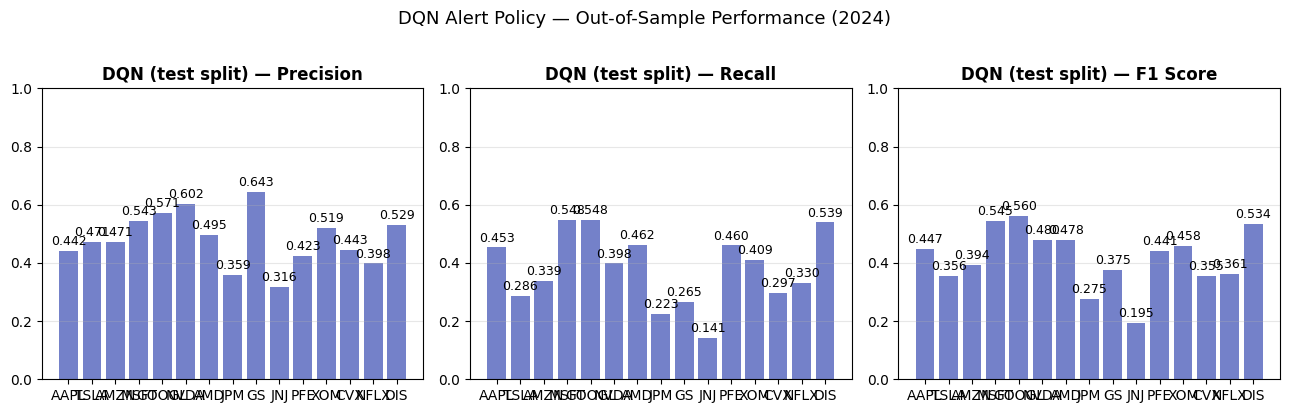

In [14]:
def evaluate_rl_agent(ticker: str) -> dict:
    """
    Run the trained agent on the held-out test split (2024).
    Agent weights are frozen — predict only, no further learning.
    """
    env    = StockAlertEnv(ticker=ticker, split='test')
    obs, _ = env.reset()
    agent  = rl_agents[ticker]

    alerts, actuals = [], []
    done = False
    while not done:
        action, _ = agent.predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(int(action))
        alerts.append(int(action))
        actuals.append(1 if env.sig[env.step_idx - 1] else 0)

    arr_a = np.array(alerts); arr_t = np.array(actuals)
    tp  = ((arr_a == 1) & (arr_t == 1)).sum()
    fp  = ((arr_a == 1) & (arr_t == 0)).sum()
    fn  = ((arr_a == 0) & (arr_t == 1)).sum()
    prec  = tp / max(tp + fp, 1)
    rec   = tp / max(tp + fn, 1)
    f1    = 2 * prec * rec / max(prec + rec, 1e-9)

    return {
        'ticker':       ticker,
        'total_alerts': int(arr_a.sum()),
        'precision':    round(prec, 3),
        'recall':       round(rec,  3),
        'f1_score':     round(f1,   3),
        'alert_rate':   round(arr_a.mean() * 100, 1)
    }

print(f"Evaluating on test split ({TEST_START} to {END_DATE})\n")
results = [evaluate_rl_agent(t) for t in TICKERS]
df_res  = pd.DataFrame(results).set_index('ticker')
print(df_res.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, ['precision', 'recall', 'f1_score']):
    bars = ax.bar(df_res.index, df_res[metric], color='#5C6BC0', alpha=0.85)
    ax.set_title(f'DQN (test split) — {metric.replace("_", " ").title()}',
                 fontweight='bold')
    ax.set_ylim(0, 1); ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, df_res[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('DQN Alert Policy — Out-of-Sample Performance (2024)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('rl_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 2: Baseline Comparison

Baseline Comparison — Test split (2024-01-01 to 2024-12-31)
                           Avg Precision  Avg Recall  Avg F1
Method                                                      
Z-Score Baseline                   0.494       0.026   0.049
IF Only                            0.381       0.040   0.072
FinSentinel (Ensemble+RL)          0.482       0.380   0.417


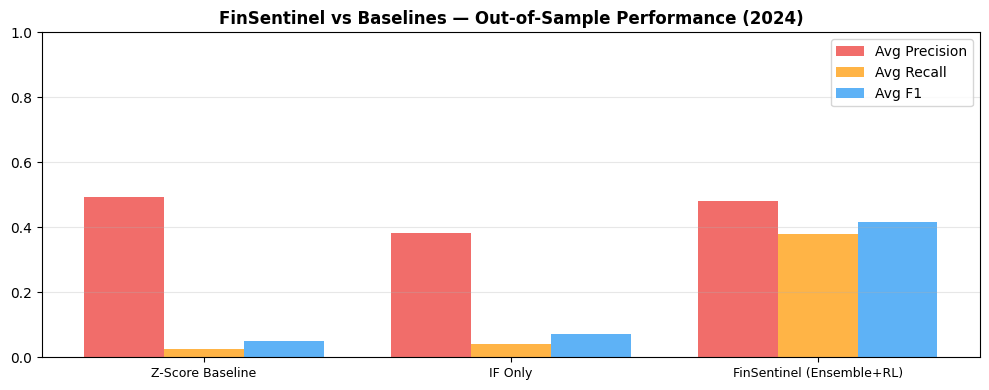

In [35]:
# All baselines evaluated on the test split only, matching the DQN evaluation window.

def zscore_baseline(ticker: str, window: int = 20, z_thresh: float = 2.5) -> np.ndarray:
    """Static z-score threshold on test-period returns."""
    rets = feature_data[ticker]['log_returns']
    test_rets = rets[rets.index >= TEST_START]
    roll_mean = test_rets.rolling(window).mean()
    roll_std  = test_rets.rolling(window).std()
    z = (test_rets - roll_mean) / (roll_std + 1e-9)
    z.dropna(inplace=True)
    return (np.abs(z) > z_thresh).astype(int).values

def if_only_baseline(ticker: str) -> np.ndarray:
    """IF scores restricted to test period."""
    scores    = if_scores[ticker]
    idx       = feature_data[ticker].index
    test_mask = idx >= TEST_START
    ts        = scores[test_mask]
    thr       = ts.mean() + 2 * ts.std()
    return (ts > thr).astype(int)

def get_ground_truth(ticker: str, n: int) -> np.ndarray:
    env = StockAlertEnv(ticker=ticker, split='test')
    gt  = env.sig[:n]
    return gt.astype(int)

def compute_metrics(pred, true):
    tp  = ((pred==1)&(true==1)).sum()
    fp  = ((pred==1)&(true==0)).sum()
    fn  = ((pred==0)&(true==1)).sum()
    prec = tp / max(tp+fp, 1)
    rec  = tp / max(tp+fn, 1)
    f1   = 2*prec*rec / max(prec+rec, 1e-9)
    return round(prec,3), round(rec,3), round(f1,3)

methods      = ['Z-Score Baseline', 'IF Only', 'FinSentinel (Ensemble+RL)']
all_results  = {m: [] for m in methods}

for ticker in TICKERS:
    env    = StockAlertEnv(ticker=ticker, split='test')
    n      = len(env.states)
    gt     = get_ground_truth(ticker, n)

    zb  = zscore_baseline(ticker)[:n]
    ifb = if_only_baseline(ticker)[:n]

    agent  = rl_agents[ticker]
    obs, _ = env.reset()
    preds, done = [], False
    while not done:
        a, _ = agent.predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(int(a))
        preds.append(int(a))
    fs_pred = np.array(preds[:n])

    for method, pred in zip(methods, [zb, ifb, fs_pred]):
        ml = min(len(pred), len(gt))
        p, r, f = compute_metrics(pred[:ml], gt[:ml])
        all_results[method].append({'ticker': ticker, 'P': p, 'R': r, 'F1': f})

rows = []
for method, res_list in all_results.items():
    avg = pd.DataFrame(res_list).mean(numeric_only=True)
    rows.append({'Method': method,
                 'Avg Precision': round(avg['P'],3),
                 'Avg Recall':    round(avg['R'],3),
                 'Avg F1':        round(avg['F1'],3)})

df_compare = pd.DataFrame(rows).set_index('Method')
print(f"Baseline Comparison — Test split ({TEST_START} to {END_DATE})")
print("="*55)
print(df_compare.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(methods)); w = 0.26
colors = ['#EF5350', '#FFA726', '#42A5F5']
for i, (metric, col) in enumerate(zip(['Avg Precision','Avg Recall','Avg F1'], colors)):
    ax.bar(x + (i-1)*w, df_compare[metric], w, label=metric, color=col, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(methods, fontsize=9)
ax.set_ylim(0, 1); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title('FinSentinel vs Baselines — Out-of-Sample Performance (2024)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 3: Ablation Study

Ablation Study — F1 Score by Pipeline Depth
        IF Only F1  Ensemble (no RL)  Full Pipeline F1
ticker                                                
AAPL         0.047             0.077             0.447
TSLA         0.063             0.032             0.356
AMZN         0.093             0.061             0.394
MSFT         0.115             0.086             0.545
GOOGL        0.059             0.015             0.560
NVDA         0.107             0.110             0.480
AMD          0.090             0.091             0.478
JPM          0.053             0.034             0.275
GS           0.103             0.087             0.375
JNJ          0.021             0.082             0.195
PFE          0.112             0.095             0.441
XOM          0.083             0.069             0.458
CVX          0.046             0.031             0.355
NFLX         0.034             0.017             0.361
DIS          0.055             0.035             0.534
MEAN         0.072   

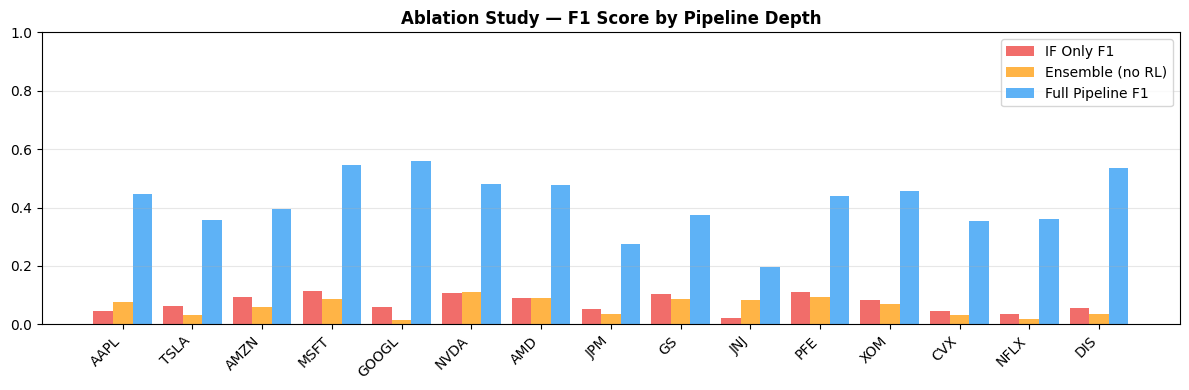

ablation chart saved


In [18]:
def ablation_if_only(ticker):
    scores = if_scores[ticker]
    idx    = feature_data[ticker].index
    test_mask = idx >= TEST_START
    ts    = scores[test_mask]
    thr   = ts.mean() + 2 * ts.std()
    pred  = (ts > thr).astype(int)
    env   = StockAlertEnv(ticker=ticker, split='test')
    gt    = env.sig
    ml    = min(len(pred), len(gt))
    pred, gt = pred[:ml], gt[:ml]
    tp = ((pred==1)&(gt==1)).sum(); fp = ((pred==1)&(gt==0)).sum()
    fn = ((pred==0)&(gt==1)).sum()
    prec = tp/max(tp+fp,1); rec = tp/max(tp+fn,1)
    f1   = 2*prec*rec/max(prec+rec,1e-9)
    return round(f1, 3)

def ablation_ensemble_no_rl(ticker):
    s     = ensemble_scores[ticker]
    test  = s[s.index >= TEST_START]
    thr   = test.quantile(0.95)
    pred  = (test > thr).astype(int).values
    env   = StockAlertEnv(ticker=ticker, split='test')
    gt    = env.sig
    ml    = min(len(pred), len(gt))
    pred, gt = pred[:ml], gt[:ml]
    tp = ((pred==1)&(gt==1)).sum(); fp = ((pred==1)&(gt==0)).sum()
    fn = ((pred==0)&(gt==1)).sum()
    prec = tp/max(tp+fp,1); rec = tp/max(tp+fn,1)
    f1   = 2*prec*rec/max(prec+rec,1e-9)
    return round(f1, 3)

def ablation_full(ticker):
    env    = StockAlertEnv(ticker=ticker, split='test')
    obs, _ = env.reset()
    preds  = []
    done   = False
    while not done:
        a, _ = rl_agents[ticker].predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(int(a))
        preds.append(int(a))
    gt   = env.sig
    pred = np.array(preds)
    ml   = min(len(pred), len(gt))
    pred, gt = pred[:ml], gt[:ml]
    tp = ((pred==1)&(gt==1)).sum(); fp = ((pred==1)&(gt==0)).sum()
    fn = ((pred==0)&(gt==1)).sum()
    prec = tp/max(tp+fp,1); rec = tp/max(tp+fn,1)
    f1   = 2*prec*rec/max(prec+rec,1e-9)
    return round(f1, 3)

ablation_rows = []
for ticker in TICKERS:
    ablation_rows.append({
        'ticker':           ticker,
        'IF Only F1':       ablation_if_only(ticker),
        'Ensemble (no RL)': ablation_ensemble_no_rl(ticker),
        'Full Pipeline F1': ablation_full(ticker)
    })

df_ablation = pd.DataFrame(ablation_rows).set_index('ticker')
means = df_ablation.mean().round(3)
df_ablation.loc['MEAN'] = means

print("Ablation Study — F1 Score by Pipeline Depth")
print("="*52)
print(df_ablation.to_string())

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(TICKERS))
w = 0.28
cols = ['#EF5350', '#FFA726', '#42A5F5']
for i, (col_name, color) in enumerate(zip(df_ablation.columns, cols)):
    ax.bar(x + (i-1)*w, df_ablation.loc[TICKERS, col_name], w,
           label=col_name, color=color, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(TICKERS, rotation=45, ha='right')
ax.set_ylim(0, 1); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title('Ablation Study — F1 Score by Pipeline Depth', fontweight='bold')
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=120, bbox_inches='tight')
plt.show()
print("ablation chart saved")

## Section 4: Statistical Significance

In [19]:
## Statistical Significance Testing
# Bootstrap confidence intervals on F1 scores

from scipy import stats as scipy_stats

def bootstrap_f1(pred, true, n_boot=1000, ci=0.95):
    f1s = []
    n   = len(pred)
    for _ in range(n_boot):
        idx  = np.random.choice(n, n, replace=True)
        p, t = pred[idx], true[idx]
        tp = ((p==1)&(t==1)).sum(); fp = ((p==1)&(t==0)).sum()
        fn = ((p==0)&(t==1)).sum()
        prec = tp/max(tp+fp,1); rec = tp/max(tp+fn,1)
        f1s.append(2*prec*rec/max(prec+rec,1e-9))
    f1s = np.array(f1s)
    lo  = np.percentile(f1s, (1-ci)/2*100)
    hi  = np.percentile(f1s, (1+ci)/2*100)
    return np.mean(f1s), lo, hi

sig_rows = []
for ticker in TICKERS:
    env    = StockAlertEnv(ticker=ticker, split='test')
    obs, _ = env.reset()
    preds  = []
    done   = False
    while not done:
        a, _ = rl_agents[ticker].predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(int(a))
        preds.append(int(a))
    pred = np.array(preds)
    gt   = env.sig[:len(pred)]
    mean_f1, lo, hi = bootstrap_f1(pred, gt)
    sig_rows.append({
        'ticker':  ticker,
        'F1 Mean': round(mean_f1, 3),
        'CI Low':  round(lo, 3),
        'CI High': round(hi, 3),
        '95% CI':  f"[{lo:.3f}, {hi:.3f}]"
    })

df_sig = pd.DataFrame(sig_rows).set_index('ticker')
print("Bootstrap 95% Confidence Intervals on F1 (n=1000 resamples)")
print("="*55)
print(df_sig[['F1 Mean', '95% CI']].to_string())
print(f"\nMean F1 across all tickers: {df_sig['F1 Mean'].mean():.3f}")


Bootstrap 95% Confidence Intervals on F1 (n=1000 resamples)
        F1 Mean          95% CI
ticker                         
AAPL      0.448  [0.374, 0.519]
TSLA      0.354  [0.262, 0.439]
AMZN      0.393  [0.309, 0.477]
MSFT      0.543  [0.467, 0.617]
GOOGL     0.561  [0.483, 0.632]
NVDA      0.478  [0.397, 0.556]
AMD       0.478  [0.396, 0.558]
JPM       0.276  [0.187, 0.364]
GS        0.374  [0.274, 0.466]
JNJ       0.193  [0.100, 0.288]
PFE       0.439  [0.358, 0.518]
XOM       0.454  [0.367, 0.534]
CVX       0.354  [0.266, 0.441]
NFLX      0.360  [0.276, 0.446]
DIS       0.532  [0.448, 0.613]

Mean F1 across all tickers: 0.416


## Section 5: Event-Anchored Validation

In [34]:
## Event-Anchored Validation
# Check if detected anomalies align with known real market events

KNOWN_EVENTS = {
    '2024-01-05': 'US jobs report beats expectations',
    '2024-01-12': 'CPI inflation data release',
    '2024-02-13': 'Hot CPI print delays rate cut expectations',
    '2024-03-20': 'Fed holds rates, signals 3 cuts in 2024',
    '2024-04-19': 'Global selloff on Middle East escalation',
    '2024-05-01': 'Fed meeting — rates held, dovish tone',
    '2024-07-11': 'CPI cooler than expected, rate cut hopes surge',
    '2024-08-05': 'Global selloff Japan carry trade unwind',
    '2024-09-18': 'Fed first rate cut 50bps',
    '2024-11-06': 'Trump election win market surge',
}

event_dates  = pd.to_datetime(list(KNOWN_EVENTS.keys()))
event_labels = list(KNOWN_EVENTS.values())
WINDOW       = 3

event_results = []

for ticker in TICKERS:
    env    = StockAlertEnv(ticker=ticker, split='test')
    obs, _ = env.reset()
    alert_dates = []
    for i in range(len(env.states) - 1):
        action, _ = rl_agents[ticker].predict(obs, deterministic=True)
        if action == 1:
            alert_dates.append(env.states_index[i])
        obs, _, done, _, _ = env.step(action)
        if done:
            break

    alert_dates = pd.to_datetime(alert_dates)
    hits = []
    for ed, el in zip(event_dates, event_labels):
        caught = any(abs((ad - ed).days) <= WINDOW for ad in alert_dates)
        hits.append({'event': el, 'date': str(ed.date()), 'caught': caught})

    hit_df   = pd.DataFrame(hits)
    hit_rate = hit_df['caught'].mean()
    event_results.append({'ticker': ticker, 'hit_rate': round(hit_rate, 3),
                          'events_caught': int(hit_df['caught'].sum())})
    print(f"{ticker}: {hit_df['caught'].sum()}/{len(hit_df)} events caught ({hit_rate:.1%})")

df_events = pd.DataFrame(event_results).set_index('ticker')
mean_hit  = df_events['hit_rate'].mean()
print(f"\nMean event hit rate across all tickers: {mean_hit:.1%}")

hit_df_all = pd.DataFrame(hits)
print("\nEvent coverage (last ticker shown as sample):")
print(hit_df_all.to_string(index=False))


AAPL: 9/10 events caught (90.0%)
TSLA: 7/10 events caught (70.0%)
AMZN: 7/10 events caught (70.0%)
MSFT: 7/10 events caught (70.0%)
GOOGL: 7/10 events caught (70.0%)
NVDA: 6/10 events caught (60.0%)
AMD: 7/10 events caught (70.0%)
JPM: 6/10 events caught (60.0%)
GS: 6/10 events caught (60.0%)
JNJ: 3/10 events caught (30.0%)
PFE: 9/10 events caught (90.0%)
XOM: 10/10 events caught (100.0%)
CVX: 7/10 events caught (70.0%)
NFLX: 7/10 events caught (70.0%)
DIS: 8/10 events caught (80.0%)

Mean event hit rate across all tickers: 70.7%

Event coverage (last ticker shown as sample):
                                         event       date  caught
             US jobs report beats expectations 2024-01-05    True
                    CPI inflation data release 2024-01-12    True
    Hot CPI print delays rate cut expectations 2024-02-13   False
       Fed holds rates, signals 3 cuts in 2024 2024-03-20    True
      Global selloff on Middle East escalation 2024-04-19    True
         Fed meeting 

## Section 6: Agentic AI Layer

In [21]:
# ─── Tool Definitions ──────────────────────────────────────────────────────────
TOOLS = [
    {
        "name": "get_anomaly_analysis",
        "description": (
            "Get the latest ML/DL ensemble anomaly score, historical stats, "
            "and RL agent decision for a given stock ticker."
        ),
        "input_schema": {
            "type": "object",
            "properties": {
                "ticker": {"type": "string", "description": "Stock ticker, e.g. AAPL"}
            },
            "required": ["ticker"]
        }
    },
    {
        "name": "get_risk_metrics",
        "description": (
            "Get recent technical risk indicators: volatility, RSI, "
            "Bollinger Band position, volume, and return for a stock."
        ),
        "input_schema": {
            "type": "object",
            "properties": {
                "ticker":       {"type": "string"},
                "lookback_days":{"type": "integer", "default": 30}
            },
            "required": ["ticker"]
        }
    },
    {
        "name": "compare_stocks",
        "description": "Rank multiple stocks by their current anomaly risk level.",
        "input_schema": {
            "type": "object",
            "properties": {
                "tickers": {
                    "type": "array",
                    "items": {"type": "string"},
                    "description": "List of ticker symbols to compare"
                }
            },
            "required": ["tickers"]
        }
    },
    {
        "name": "generate_alert_report",
        "description": (
            "Generate a structured analyst-style alert report for a stock, "
            "summarising anomaly evidence and recommended action."
        ),
        "input_schema": {
            "type": "object",
            "properties": {
                "ticker":        {"type": "string"},
                "anomaly_score": {"type": "number"},
                "rl_decision":   {"type": "string"},
                "risk_level":    {"type": "string",
                                  "enum": ["LOW", "MEDIUM", "HIGH", "CRITICAL"]}
            },
            "required": ["ticker", "anomaly_score", "rl_decision", "risk_level"]
        }
    }
]

# ─── Tool Implementations ──────────────────────────────────────────────────────
def execute_tool(name: str, inp: dict) -> dict:
    if name == "get_anomaly_analysis":
        ticker = inp["ticker"].upper()
        if ticker not in ensemble_scores:
            return {"error": f"{ticker} not in pipeline"}

        s   = ensemble_scores[ticker]
        thr = s.quantile(ALERT_THRESH)
        cur = float(s.iloc[-1])

        env = StockAlertEnv(ticker=ticker)
        a, _ = rl_agents[ticker].predict(env.states[-1], deterministic=True)
        rl_dec = "ALERT" if a == 1 else "MONITOR"

        top5 = s[s > thr].tail(5).index.strftime('%Y-%m-%d').tolist()

        return {
            "ticker": ticker,
            "current_anomaly_score": round(cur, 4),
            "threshold_95pct":       round(float(thr), 4),
            "is_anomalous":          cur > thr,
            "5d_avg_score":          round(float(s.tail(5).mean()), 4),
            "rl_recommendation":     rl_dec,
            "recent_anomaly_dates":  top5
        }

    elif name == "get_risk_metrics":
        ticker = inp["ticker"].upper()
        n      = inp.get("lookback_days", 30)
        if ticker not in feature_data:
            return {"error": f"{ticker} not found"}

        f = feature_data[ticker].tail(n)
        p = stock_data[ticker]['Close'].tail(n)

        return {
            "ticker": ticker,
            "lookback_days":        n,
            "avg_volatility_20d":   round(float(f['volatility_20'].mean()), 5),
            "current_rsi":          round(float(f['rsi_norm'].iloc[-1] * 50 + 50), 2),
            "rsi_signal":           ("Overbought" if f['rsi_norm'].iloc[-1] > 0.4
                                     else "Oversold" if f['rsi_norm'].iloc[-1] < -0.4
                                     else "Neutral"),
            "volume_ratio_avg":     round(float(f['volume_ratio'].mean()), 3),
            "bb_position":          round(float(f['bb_pos'].iloc[-1]), 3),
            "period_return_pct":    round(float((p.iloc[-1]/p.iloc[0]-1)*100), 2),
            "max_drawdown_pct":     round(float(((p/p.cummax())-1).min()*100), 2)
        }

    elif name == "compare_stocks":
        out = []
        for t in [x.upper() for x in inp["tickers"]]:
            if t in ensemble_scores:
                s   = ensemble_scores[t]
                cur = float(s.iloc[-1])
                thr = float(s.quantile(ALERT_THRESH))
                pct = float((s < cur).mean() * 100)
                out.append({
                    "ticker": t,
                    "anomaly_score":   round(cur, 4),
                    "risk_level":      ("CRITICAL" if cur > thr * 1.2
                                        else "HIGH"   if cur > thr
                                        else "MEDIUM" if cur > thr * 0.8
                                        else "LOW"),
                    "percentile_rank": round(pct, 1)
                })
        out.sort(key=lambda x: x['anomaly_score'], reverse=True)
        return {"comparison": out,
                "highest_risk": out[0]["ticker"] if out else None}

    elif name == "generate_alert_report":
        t = inp["ticker"]
        return {
            "report_id":       f"FS-{t}-{datetime.now().strftime('%Y%m%d-%H%M')}",
            "generated_at":    datetime.now().isoformat(),
            "ticker":          t,
            "risk_level":      inp["risk_level"],
            "anomaly_score":   inp["anomaly_score"],
            "rl_decision":     inp["rl_decision"],
            "action_required": inp["rl_decision"] == "ALERT",
            "headline": (
                f"⚠️ ANOMALY ALERT: {t} flagged at score {inp['anomaly_score']:.4f} "
                f"— Risk Level {inp['risk_level']}"
                if inp["rl_decision"] == "ALERT"
                else f"✅ {t} within normal parameters — Monitoring active"
            )
        }

    return {"error": f"Unknown tool: {name}"}

print("✅ Tool definitions and implementations ready")


✅ Tool definitions and implementations ready


In [29]:
from google.colab import userdata
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

In [30]:
class FinSentinelAgent:
    """
    Agentic AI orchestrator.
    Uses Groq + Llama to autonomously analyse pipeline outputs
    and generate analyst-style reports.
    """

    SYSTEM = """You are FinSentinel, an AI analyst specialising in stock market anomaly detection. You have access to a proprietary ML+DL+RL pipeline.

For any query:
1. Analyse the provided anomaly scores and alert flags
2. Rank stocks by risk where relevant
3. Identify which tickers need immediate attention
4. Deliver a clear, structured assessment with specific numbers

Be concise, data-driven, and professional. Always cite the anomaly scores."""

    def __init__(self, api_key: str):
         self.client = groq.Groq(api_key=api_key)

    def run(self, query: str) -> str:
        print(f"\n{'='*60}")
        print(f"FinSentinel Agent Query: {query[:80]}...")
        print('='*60)

        context = []
        for ticker in TICKERS:
            s = ensemble_scores[ticker]
            latest_score = float(s.iloc[-1])
            alert = latest_score > s.quantile(ALERT_THRESH)
            context.append(f"{ticker}: score={latest_score:.4f} alert={'YES' if alert else 'NO'}")

        context_str = "\n".join(context)

        messages = [
            {"role": "system", "content": self.SYSTEM},
            {"role": "user", "content": f"Pipeline output:\n{context_str}\n\nQuery: {query}"}
        ]

        resp = self.client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            max_tokens=2000,
            messages=messages
        )

        text = resp.choices[0].message.content
        print(f"\nAgent Response:\n{text}")
        return text


agent = FinSentinelAgent(api_key=userdata.get("GROQ_API_KEY"))
print("FinSentinel Agent initialised")

FinSentinel Agent initialised


In [31]:


DEMO_QUERIES = [
    "Scan all 5 stocks and rank them by current anomaly risk. "
    "Flag any that need immediate attention.",

    "Give me a deep-dive on TSLA — is there unusual activity? "
    "What does the RL agent recommend and why?",

    "Compare AAPL and MSFT. Which one has elevated anomaly risk "
    "and what are the key indicators driving it?"
]

agent_reports = {}

for q in DEMO_QUERIES:
    report = agent.run(q)
    agent_reports[q[:50]] = report
    print()

print("\n✅ All agent queries complete")



FinSentinel Agent Query: Scan all 5 stocks and rank them by current anomaly risk. Flag any that need imme...

Agent Response:
Based on the pipeline output, I've scanned the provided data, but it appears only 15 stocks are available, not 5 specific ones to rank. However, I can rank all 15 stocks by their anomaly scores, which indicate the level of risk.

Here's the ranking from highest to lowest anomaly score:
1. GOOGL: score=0.2836
2. NVDA: score=0.2672
3. XOM: score=0.2494
4. AMZN: score=0.2581
5. AMD: score=0.2247
6. PFE: score=0.1988
7. DIS: score=0.1941
8. TSLA: score=0.1898
9. CVX: score=0.1835
10. MSFT: score=0.1757
11. GS: score=0.1397
12. AAPL: score=0.1252
13. JPM: score=0.1123
14. JNJ: score=0.0750
15. NFLX: score=0.0580

Since none of the stocks have an alert flag set to "YES", none of them require immediate attention based on the provided data. However, stocks with higher anomaly scores like GOOGL (0.2836) and NVDA (0.2672) should be closely monitored for potential future 

## Section 7: End-to-End Pipeline Demo

In [32]:
def finsentinel_pipeline(ticker: str, verbose: bool = True) -> dict:
    """
    Full FinSentinel pipeline for a single ticker:
    1. Feature engineering (already done)
    2. IF anomaly score
    3. LSTM AE reconstruction score
    4. Ensemble scoring
    5. RL alert decision
    6. Agentic report (if anomaly detected)

    Returns a structured result dict.
    """
    s   = ensemble_scores[ticker]
    cur = float(s.iloc[-1])
    thr = float(s.quantile(ALERT_THRESH))

    env      = StockAlertEnv(ticker=ticker)
    rl_act, _ = rl_agents[ticker].predict(env.states[-1], deterministic=True)
    rl_dec   = "ALERT" if rl_act == 1 else "MONITOR"

    risk = ("CRITICAL" if cur > thr * 1.2
            else "HIGH"   if cur > thr
            else "MEDIUM" if cur > thr * 0.8
            else "LOW")

    result = {
        "ticker":          ticker,
        "timestamp":       datetime.now().isoformat(),
        "ensemble_score":  round(cur, 4),
        "threshold_95":    round(thr, 4),
        "is_anomaly":      cur > thr,
        "risk_level":      risk,
        "rl_decision":     rl_dec,
        "if_score":        round(float(if_scores[ticker][-1]), 4),
        "lstm_score":      round(float(lstm_scores[ticker][-1]), 4),
    }

    if verbose:
        icon = "🔴" if result['is_anomaly'] else "🟢"
        print(f"{icon} {ticker:6s} | Score={cur:.4f} (thr={thr:.4f}) "
              f"| Risk={risk:8s} | RL={rl_dec}")

    return result

print(" Running full FinSentinel pipeline across portfolio...\n")
pipeline_results = [finsentinel_pipeline(t) for t in TICKERS]
df_final = pd.DataFrame(pipeline_results).set_index('ticker')
print()
print(df_final[['ensemble_score','threshold_95','is_anomaly',
                'risk_level','rl_decision']].to_string())
print("\n Pipeline complete")


 Running full FinSentinel pipeline across portfolio...

🟢 AAPL   | Score=0.1252 (thr=0.3353) | Risk=LOW      | RL=ALERT
🟢 TSLA   | Score=0.1898 (thr=0.4234) | Risk=LOW      | RL=MONITOR
🟢 AMZN   | Score=0.2581 (thr=0.6054) | Risk=LOW      | RL=ALERT
🟢 MSFT   | Score=0.1757 (thr=0.2639) | Risk=LOW      | RL=MONITOR
🟢 GOOGL  | Score=0.2836 (thr=0.4054) | Risk=LOW      | RL=MONITOR
🟢 NVDA   | Score=0.2672 (thr=0.4872) | Risk=LOW      | RL=ALERT
🟢 AMD    | Score=0.2247 (thr=0.4245) | Risk=LOW      | RL=ALERT
🟢 JPM    | Score=0.1123 (thr=0.2721) | Risk=LOW      | RL=ALERT
🟢 GS     | Score=0.1397 (thr=0.2716) | Risk=LOW      | RL=MONITOR
🟢 JNJ    | Score=0.0750 (thr=0.2345) | Risk=LOW      | RL=ALERT
🟢 PFE    | Score=0.1988 (thr=0.4044) | Risk=LOW      | RL=ALERT
🟢 XOM    | Score=0.2494 (thr=0.3128) | Risk=LOW      | RL=MONITOR
🟢 CVX    | Score=0.1835 (thr=0.2429) | Risk=LOW      | RL=MONITOR
🟢 NFLX   | Score=0.0580 (thr=0.2623) | Risk=LOW      | RL=MONITOR
🟢 DIS    | Score=0.1941 (thr=0.355

In [33]:
import os, json

os.makedirs('outputs', exist_ok=True)


for ticker in TICKERS:
    ensemble_scores[ticker].to_csv(f'outputs/{ticker}_anomaly_scores.csv')


with open('outputs/pipeline_results.json', 'w') as f:
    json.dump(pipeline_results, f, indent=2, default=str)

df_res.to_csv('outputs/rl_metrics.csv')

df_compare.to_csv('outputs/baseline_comparison.csv')

print(" All outputs saved to outputs/ directory")
print("   Files:", os.listdir('outputs'))


 All outputs saved to outputs/ directory
   Files: ['GOOGL_anomaly_scores.csv', 'JNJ_anomaly_scores.csv', 'GS_anomaly_scores.csv', 'AMZN_anomaly_scores.csv', 'NFLX_anomaly_scores.csv', 'pipeline_results.json', 'CVX_anomaly_scores.csv', 'rl_metrics.csv', 'PFE_anomaly_scores.csv', 'baseline_comparison.csv', 'AAPL_anomaly_scores.csv', 'TSLA_anomaly_scores.csv', 'XOM_anomaly_scores.csv', 'AMD_anomaly_scores.csv', 'JPM_anomaly_scores.csv', 'NVDA_anomaly_scores.csv', 'MSFT_anomaly_scores.csv', 'DIS_anomaly_scores.csv']
